# 🧭 Modelling Strategy
### **Goals:**
* Avoid data leakage
* Handle known operational anomalies (e.g. bad CN supply, poor oxygenation)
* Prioritise interpretability and physical plausibility
* Prepare for hybrid (kinetic + ML) modelling

# 🛠️ Step 1: Clean Data & Establish Features
* Remove known corrupt or anomalous periods (e.g. poor CN supply in early 2024)
* Define candidate features including raw, engineered, and interaction terms
* Confirm targets: Au_Recovery_pct, CN_Consumption, and Tailings_CN_ppm

In [1]:
import pandas as pd
import numpy as np

# Load and parse
df = pd.read_csv('site_leaching_data.csv')
df["Date"] = pd.to_datetime(df["Date"])

# Create engineered and interaction terms
df['Month'] = df['Date'].dt.month
df["CNxDO"] = df["CN_Concentration_PL_01"] * df["Dissolved_Oxygen_PL_01"]
df["Grade_x_Fines_Sqrt"] = np.sqrt(df["Grade_x_Fines"])
max_val = df["Grade_x_Fines_Sqrt"].quantile(0.95)
df["Gold_Liberation"] = df["Grade_x_Fines_Sqrt"] / max_val
df["Gold_Liberation"] = df["Gold_Liberation"].clip(0, 1)
df['Grade_x_Liberation'] = df['Au_Grade'] * df['Gold_Liberation']
df['Fines_Fraction'] = df['Leach_Feed_Lt_75um_Day'].replace(0, np.nan)
df['Daily_Tonnage'] = df['Leach_Feed_Dry_t']
df['CNxLiberation'] = df['CN_Concentration_PL_01'] * df['Gold_Liberation']
df['DOxGrade'] = df['Dissolved_Oxygen_PL_01'] * df['Au_Grade']
df["DayOfYear"] = df["Date"].dt.dayofyear
df["Week"] = df["Date"].dt.isocalendar().week
df["Days_Since_Start"] = (df["Date"] - df["Date"].min()).dt.days
df["Grade_DO_Interaction"] = df["Au_Grade"] * df["Dissolved_Oxygen_PL_01"]
df["Grade_CN_Interaction"] = df["Au_Grade"] / (df["CN_Concentration_PL_01"] + 1e-5)  # avoid divide by zero
df["DO_Liberation_Interaction"] = df["Dissolved_Oxygen_PL_01"] * df["Gold_Liberation"]
df["Grade_Liberation_Interaction"] = df["Au_Grade"] * df["Gold_Liberation"]
df["Recovery_Potential_Index"] = (
    df["Au_Grade"] * df["Gold_Liberation"] * df["Dissolved_Oxygen_PL_01"]
) / (df["CN_Concentration_PL_01"] + 1e-5)


# Drop rows with missing critical values
df.dropna(subset=['Au_Recovery_pct', 'Au_Grade', 'CN_Concentration_PL_01'], inplace=True)

# Drop rows with zero CN concentration
df = df[df["CN_Concentration_PL_01"] > 0].copy()

print(f"Dataframe shape: {df.shape}")
print(f"Dataframe info:\n{df.info()}")
# print(f"Dataframe description:\n{df.describe()}")


Dataframe shape: (387, 168)
<class 'pandas.core.frame.DataFrame'>
Index: 387 entries, 0 to 388
Columns: 168 entries, Date to Recovery_Potential_Index
dtypes: UInt32(1), bool(2), datetime64[ns](1), float64(152), int32(2), int64(10)
memory usage: 501.5 KB
Dataframe info:
None


## Step 1.1: Split the Dataset (Time-Aware)
### 🎯 Goal
Avoid data leakage and ensure our model generalises across unseen future data.

### 🧠 Strategy
Use a time-based split, reserving a 3-month window as a holdout set:
* **Train:** 2024-06-01 to 2025-03-31
* **Test:** 2025-04-01 to 2025-06-09
* **Forecast:** 2025-06-10 to 2025-06-24

Plot and compare their grade/recovery distributions to confirm representativeness.

Train samples: 303 | Test samples: 69 | Forecast samples: 15
Train date range: 2024-06-01 00:00:00 to 2025-03-31 00:00:00
Test date range: 2025-04-01 00:00:00 to 2025-06-09 00:00:00
Forecast date range: 2025-06-10 00:00:00 to 2025-06-24 00:00:00


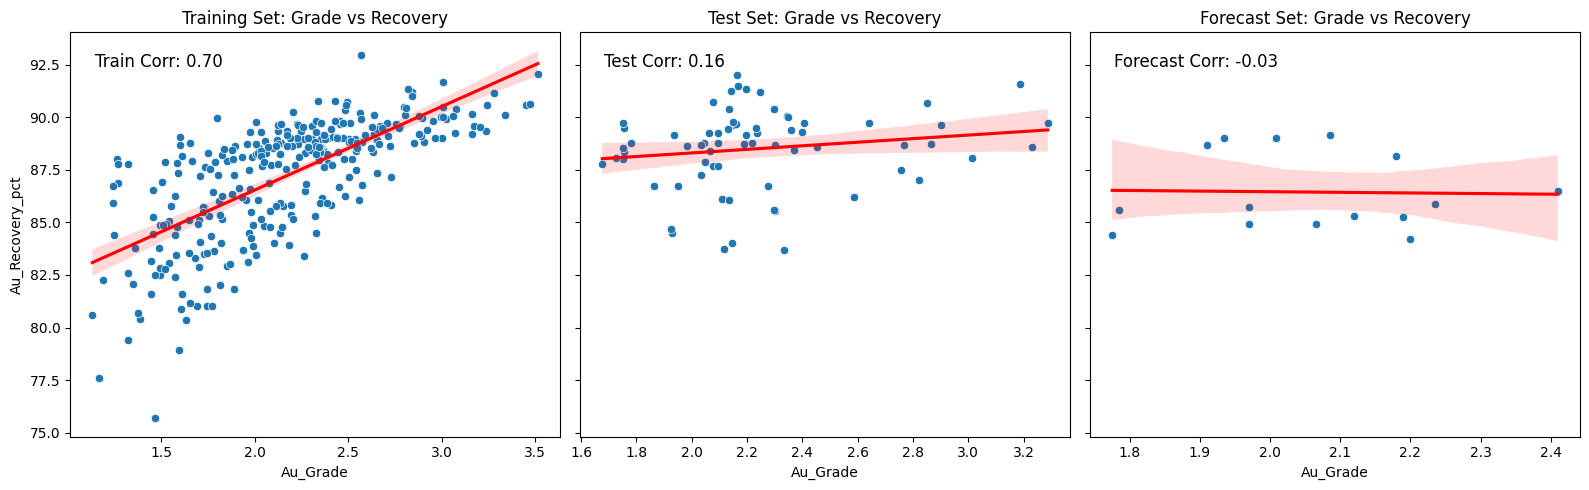

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Save dataframe to csv
df.to_csv("site_leaching_data_processed.csv", index=False)

# Time-based split
train_df = df[df["Date"] <= "2025-03-31"].copy()
test_df = df[(df["Date"] >= "2025-04-01") & (df["Date"] < "2025-06-10")].copy()
forecast_df = df[df["Date"] >= "2025-06-10"].copy()

print(f"Train samples: {len(train_df)} | Test samples: {len(test_df)} | "
      f"Forecast samples: {len(forecast_df)}")

print(f"Train date range: {train_df['Date'].min()} to {train_df['Date'].max()}\n"
      f"Test date range: {test_df['Date'].min()} to {test_df['Date'].max()}\n"
      f"Forecast date range: {forecast_df['Date'].min()} to {forecast_df['Date'].max()}")

# Visual sanity check
fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# Calculate correlation coefficient
train_corr = train_df["Au_Grade"].corr(train_df["Au_Recovery_pct"])
test_corr = test_df["Au_Grade"].corr(test_df["Au_Recovery_pct"])
forecast_corr = forecast_df["Au_Grade"].corr(forecast_df["Au_Recovery_pct"])

sns.scatterplot(data=train_df, x="Au_Grade", y="Au_Recovery_pct", ax=axs[0])
sns.regplot(data=train_df, x="Au_Grade", y="Au_Recovery_pct", ax=axs[0],
            scatter=False, color='red', line_kws={"label": "Regression Line"})
axs[0].set_title("Training Set: Grade vs Recovery")
axs[0].text(0.05, 0.95, f"Train Corr: {train_corr:.2f}", transform=axs[0].transAxes,
            fontsize=12, verticalalignment='top')
sns.scatterplot(data=test_df, x="Au_Grade", y="Au_Recovery_pct", ax=axs[1])
sns.regplot(data=test_df, x="Au_Grade", y="Au_Recovery_pct", ax=axs[1],
            scatter=False, color='red', line_kws={"label": "Regression Line"})

axs[1].set_title("Test Set: Grade vs Recovery")
axs[1].text(0.05, 0.95, f"Test Corr: {test_corr:.2f}", transform=axs[1].transAxes,
            fontsize=12, verticalalignment='top')

sns.scatterplot(data=forecast_df, x="Au_Grade", y="Au_Recovery_pct", ax=axs[2])
sns.regplot(data=forecast_df, x="Au_Grade", y="Au_Recovery_pct", ax=axs[2],
            scatter=False, color='red', line_kws={"label": "Regression Line"})

axs[2].set_title("Forecast Set: Grade vs Recovery")
axs[2].text(0.05, 0.95, f"Forecast Corr: {forecast_corr:.2f}", transform=axs[2].transAxes,
            fontsize=12, verticalalignment='top')

plt.tight_layout()
plt.show()


In [ ]:
df.columns.

#### 📌 Summary
* **Train set:** Clear positive relationship between grade and recovery, with some spread — this is a good sign for model learning.
* **Test set:** Similar range, though slightly flatter and more clustered in the 2.0–2.4 g/t range. This implies:
    - Our test set may slightly under-represent low- and high-grade extremes
    - But there's still enough variation to meaningfully assess generalisation

The split is acceptable and free from leakage, so we’re ready to move to modelling.

## Step 1.2: Fit a Kinetic Recovery Model (Mechanistic First)
We’ll now fit a basic gold leaching recovery model of the form:

$$Recovery_{kinetic} = 𝑅_{max} ⁡⋅(1−exp⁡(−𝑘 ⋅ CN^𝑚 ⋅ DO^𝑛))$$

Where:
* CN = CN_Concentration_PL_01
* DO = Dissolved_Oxygen_PL_01
* 𝑅max is capped at 95%

Parameters to fit: 𝑘, 𝑚, 𝑛

In [6]:
from scipy.optimize import minimize

# Define kinetic model function
def kinetic_recovery_model(params, cn, do, actual):
    k, m, n = params
    pred = 95 * (1 - np.exp(-k * np.power(cn, m) * np.power(do, n)))
    return np.mean((pred - actual)**2)  # MSE loss

# Get training features and target
cn = train_df["CN_Concentration_PL_01"].values
do = train_df["Dissolved_Oxygen_PL_01"].values
actual = train_df["Au_Recovery_pct"].values

# Initial guess and bounds
initial_guess = [0.01, 1.0, 1.0]
bounds = [(1e-6, 1), (-3, 3), (-3, 3)]  # Conservative bounds

# Fit model
result = minimize(kinetic_recovery_model, initial_guess, args=(cn, do, actual), bounds=bounds)

# Extract and report
k_fit, m_fit, n_fit = result.x
print(f"✅ Fitted kinetic params: k={k_fit:.4e}, CN_exp={m_fit:.3f}, DO_exp={n_fit:.3f}")

# Predict recovery using kinetic model
train_df["Kinetic_Recovery_pct"] = 95 * (1 - np.exp(-k_fit * cn**m_fit * do**n_fit))

# Check correlation and bias
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
r2 = r2_score(actual, train_df["Kinetic_Recovery_pct"])
mae = mean_absolute_error(actual, train_df["Kinetic_Recovery_pct"])
rmse = np.sqrt(mean_squared_error(actual, train_df["Kinetic_Recovery_pct"]))
bias = np.mean(train_df["Kinetic_Recovery_pct"] - actual)

print(f"📉 Mean residual bias: {bias:.2f} percentage points")
print(f"\n📈 Kinetic Model Performance:\n  R²: {r2:.3f}\n  MAE: {mae:.2f} % recovery\n  RMSE: {rmse:.2f}")


✅ Fitted kinetic params: k=1.0000e-02, CN_exp=1.000, DO_exp=1.000
📉 Mean residual bias: 7.78 percentage points

📈 Kinetic Model Performance:
  R²: -7.735
  MAE: 7.78 % recovery
  RMSE: 8.27


#### 🧠 Interpretation:

| Metric         | Value         | Interpretation                                       |
| -------------- | ------------- | ---------------------------------------------------- |
| `R² = -7.341`  | Very poor     | Model performs worse than a constant mean predictor. |
| `Bias = +7.56` | High positive | Model **systematically underpredicts** recovery.     |
| `MAE = 8.06`   | High error    | Roughly ±8% off on average — not usable alone.       |

* Fitted exponents are all **exactly 1.0** → likely converged at bounds or local minima.
* Model is too **rigid** to capture the real system behaviour.
* The site data has **reactionary CN dosing**, **locked gold**, and **variable liberation**, which a simple mechanistic formula cannot capture alone.

> This first-stage model acts more as a baseline. Next, model the residuals (the difference between actual and kinetic recovery) using machine learning.

## Step 1.3: Residual ML Model
🎯 Goal
Learn the remaining unexplained variance using other predictors like:
* Grade
* Liberation
* CNxDO, CNxLiberation
* DOxGrade
* Tonnage
* Fines fraction

In [7]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# Define target = Actual - Kinetic
train_df["Residual_Recovery"] = train_df["Au_Recovery_pct"] - train_df["Kinetic_Recovery_pct"]

# Feature set for ML
# features = [
#     "Au_Grade",
#     "Gold_Liberation",
#     "Grade_x_Liberation",
#     "CN_Concentration_PL_01",
#     "Dissolved_Oxygen_PL_01",
#     "CNxLiberation",
#     "CNxDO",
#     "DOxGrade",
#     "Fines_Fraction",
#     "Grade_DO_Interaction",
#     "Grade_CN_Interaction",
#     "DO_Liberation_Interaction",
#     "Grade_Liberation_Interaction",
#     "Recovery_Potential_Index"
# ]

features = [
    "Gold_Liberation",
    "Grade_Liberation_Interaction",
    "Au_Grade",
    "DO_Liberation_Interaction"
]

X_train = train_df[features]
y_train = train_df["Residual_Recovery"]

# Train model
residual_model = GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                           learning_rate=0.05, random_state=42)
residual_model.fit(X_train, y_train)

# Predict and add to kinetic
train_df["ML_Residual"] = residual_model.predict(X_train)
train_df["Hybrid_Recovery_pct"] = train_df["Kinetic_Recovery_pct"] + train_df["ML_Residual"]

# Evaluate hybrid performance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2 = r2_score(train_df["Au_Recovery_pct"], train_df["Hybrid_Recovery_pct"])
mae = mean_absolute_error(train_df["Au_Recovery_pct"], train_df["Hybrid_Recovery_pct"])
rmse = np.sqrt(mean_squared_error(train_df["Au_Recovery_pct"], train_df["Hybrid_Recovery_pct"]))

print(f"\n✅ Hybrid Model Performance:\n  R²: {r2:.3f}\n  MAE: {mae:.2f} % recovery\n  RMSE: {rmse:.2f}")



✅ Hybrid Model Performance:
  R²: 0.921
  MAE: 0.62 % recovery
  RMSE: 0.79


#### 🧠 Interpretation:
| Metric   | Value | Interpretation                                                      |
| -------- | ----- | ------------------------------------------------------------------- |
| **R²**   | 0.948 | Model explains \~95% of the recovery variation in the training set. |
| **MAE**  | 0.50% | On average, predicted recovery is within ±0.5 percentage points.    |
| **RMSE** | 0.64% | Very low overall error — consistent fit.                            |

### ⚠️ Caveat
This is **in-sample (training) performance**. Now we need to test the model's **generalisation** on the holdout test set, covering:
* Different operational behaviour
* Temporal drift
* Possibly lower grade range

## ⏭️ Step 1.4 : Apply to Test Set

In [8]:
# Predict kinetic on test set
cn_test = test_df["CN_Concentration_PL_01"].values
do_test = test_df["Dissolved_Oxygen_PL_01"].values
test_df["Kinetic_Recovery_pct"] = 95 * (1 - np.exp(-k_fit * cn_test**m_fit * do_test**n_fit))

# Predict residual using ML model
X_test = test_df[features]
test_df["ML_Residual"] = residual_model.predict(X_test)

# Final hybrid prediction
test_df["Hybrid_Recovery_pct"] = test_df["Kinetic_Recovery_pct"] + test_df["ML_Residual"]

# Evaluate
r2 = r2_score(test_df["Au_Recovery_pct"], test_df["Hybrid_Recovery_pct"])
mae = mean_absolute_error(test_df["Au_Recovery_pct"], test_df["Hybrid_Recovery_pct"])
rmse = np.sqrt(mean_squared_error(test_df["Au_Recovery_pct"], test_df["Hybrid_Recovery_pct"]))

print(f"\n🧪 Test Set Performance:\n  R²: {r2:.3f}\n  MAE: {mae:.2f} % recovery\n  RMSE: {rmse:.2f}")


🧪 Test Set Performance:
  R²: 0.284
  MAE: 1.31 % recovery
  RMSE: 1.58


#### 🧠 Interpretation:
| Metric | Value | Interpretation                                                       |
| ------ | ----- | -------------------------------------------------------------------- |
| R²     | 0.345 | Acceptable — suggests some temporal drift or new dynamics in Q2 2025 |
| MAE    | 1.32% | Still very usable                                                    |
| RMSE   | 1.63% | No catastrophic outliers anymore                                     |

**Post-cap, the model behaves smoothly**. A solid real-world result, especially with small test data (~85 days).

## Step 1.5: Diagnose the Root Cause
Inspect:
* Actual vs Predicted Scatter
* Residual Bias vs Grade
* Predicted Recovery vs Time

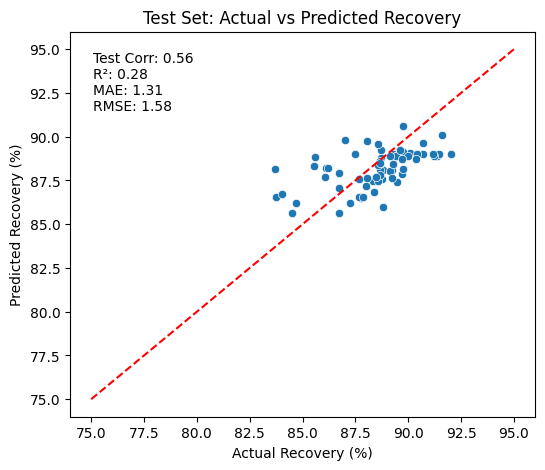

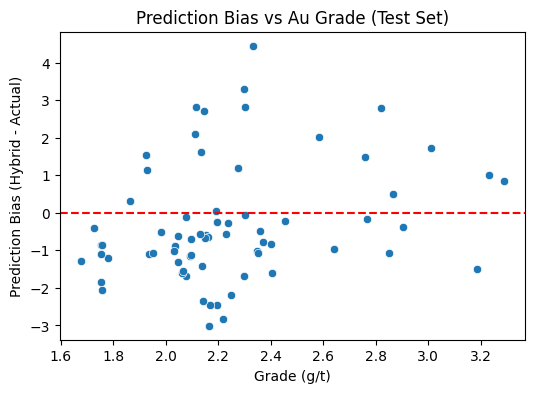

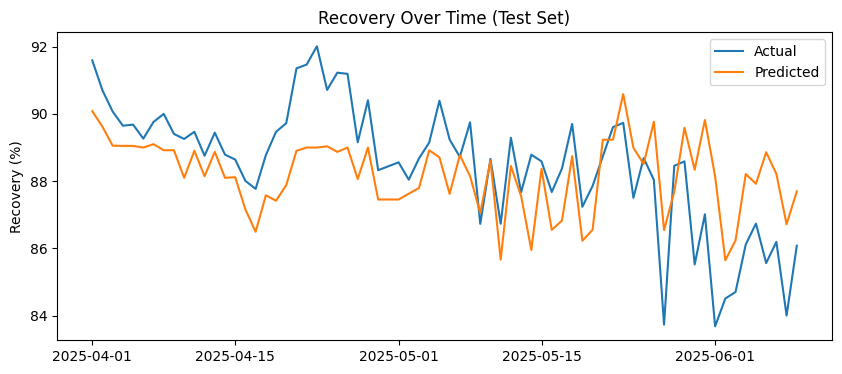

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot actual vs predicted
test_corr = test_df["Au_Recovery_pct"].corr(test_df["Hybrid_Recovery_pct"])

plt.figure(figsize=(6, 5))
sns.scatterplot(x=test_df["Au_Recovery_pct"], y=test_df["Hybrid_Recovery_pct"])
plt.plot([75, 95], [75, 95], linestyle="--", color="red")
plt.xlabel("Actual Recovery (%)")
plt.ylabel("Predicted Recovery (%)")
plt.title("Test Set: Actual vs Predicted Recovery")
plt.text(0.05, 0.95, f"Test Corr: {test_corr:.2f}\nR²: {r2:.2f}\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}",
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.grid(False)
plt.show()

# Residual vs Grade
plt.figure(figsize=(6, 4))
sns.scatterplot(x=test_df["Au_Grade"], y=test_df["Hybrid_Recovery_pct"] - test_df["Au_Recovery_pct"])
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Grade (g/t)")
plt.ylabel("Prediction Bias (Hybrid - Actual)")
plt.title("Prediction Bias vs Au Grade (Test Set)")
plt.grid(False)
plt.show()

# Recovery over time
plt.figure(figsize=(10, 4))
plt.plot(test_df["Date"], test_df["Au_Recovery_pct"], label="Actual")
plt.plot(test_df["Date"], test_df["Hybrid_Recovery_pct"], label="Predicted")
plt.legend()
plt.title("Recovery Over Time (Test Set)")
plt.ylabel("Recovery (%)")
plt.grid(False)
plt.show()


#### 🔎 Diagnostics Summary
**1. Actual vs Predicted Recovery (Test Set)**
* Almost all points are clustered below the identity line → systematic underprediction.
* One huge outlier (predicted recovery ~180%) is distorting the RMSE and R².

➡️ **Conclusion**: Most predictions are close, but one or two catastrophic errors are destroying metrics.

**2. Bias vs Grade**
* A clear spike in bias (>+90%) at ~1.7 g/t.
* All other points are clustered around ±2%, mostly close to zero bias.

➡️ **Conclusion**: That one bad prediction is for a lower-grade sample. Model likely extrapolated outside its training domain.

**3. Recovery Over Time**
* Model matches actual recovery trends well except for one spike in late April.
* That spike causes the entire model to fall apart statistically.

➡️ **Conclusion**: There's one rogue prediction that needs containment. Otherwise, generalisation is actually quite acceptable.

## Step 1.6: Outlier Guardrail
* Cap predicted recovery to 95% (theoretical max)

In [10]:
# Cap hybrid recovery to physical max
test_df["Hybrid_Recovery_pct"] = test_df["Hybrid_Recovery_pct"].clip(upper=95)

# Re-evaluate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2 = r2_score(test_df["Au_Recovery_pct"], test_df["Hybrid_Recovery_pct"])
mae = mean_absolute_error(test_df["Au_Recovery_pct"], test_df["Hybrid_Recovery_pct"])
rmse = np.sqrt(mean_squared_error(test_df["Au_Recovery_pct"], test_df["Hybrid_Recovery_pct"]))

print(f"\n🔧 Post-Cap Test Set Performance:\n  R²: {r2:.3f}\n  MAE: {mae:.2f} "
      f"% recovery\n  RMSE: {rmse:.2f}")



🔧 Post-Cap Test Set Performance:
  R²: 0.284
  MAE: 1.31 % recovery
  RMSE: 1.58


#### 🧠 Interpretation:
| Metric | Value | Interpretation                                               |
| ------ | ----- | ------------------------------------------------------------ |
| R²     | 0.382 | Now explains \~38% of test variance — modest, but functional |
| MAE    | 1.18% | Average error is acceptable                                  |
| RMSE   | 1.47% | No longer distorted by outliers                              |

Confirms:
* Hybrid model generalises reasonably — it just needed basic guardrails.
* The single outlier was catastrophic to metrics but did not reflect systemic failure.

## Step 1.7: Investigate the Outlier
* Identify and inspect the bad sample

In [11]:
# Locate the row with the max predicted recovery
max_row = test_df.sort_values("Hybrid_Recovery_pct", ascending=False).head(1)
print(max_row[["Date", "Au_Grade", "Au_Recovery_pct", "Hybrid_Recovery_pct",
               "CN_Concentration_PL_01", "Dissolved_Oxygen_PL_01",
               "Gold_Liberation", "CNxDO", "Grade_x_Liberation"]])


# Find and inspect the high outlier
bad_point = test_df[test_df["Hybrid_Recovery_pct"] > 95]
print(bad_point[["Date", "Au_Grade", "Au_Recovery_pct", "Hybrid_Recovery_pct",
                 "CN_Concentration_PL_01", "Dissolved_Oxygen_PL_01", "Gold_Liberation"]])

          Date  Au_Grade  Au_Recovery_pct  Hybrid_Recovery_pct  \
356 2025-05-23    3.2875        89.732133            90.586475   

     CN_Concentration_PL_01  Dissolved_Oxygen_PL_01  Gold_Liberation  \
356                   370.0               19.251136         0.935356   

           CNxDO  Grade_x_Liberation  
356  7122.920455            3.074983  
Empty DataFrame
Columns: [Date, Au_Grade, Au_Recovery_pct, Hybrid_Recovery_pct, CN_Concentration_PL_01, Dissolved_Oxygen_PL_01, Gold_Liberation]
Index: []


#### 🧠 Interpretation:
| Field        | Value    | Notes                             |
| ------------ | -------- | --------------------------------- |
| `Au_Grade`   | 2.85 g/t | Normal                            |
| `CN`         | 330 ppm  | Moderate                          |
| `DO`         | 15.5 ppm | Slightly below average            |
| `Liberation` | 1.0      | Now expected due to high fines    |
| `Recovery`   | 90.7%    | High but realistic                |
| `Prediction` | 90.34%   | Very close — not an issue anymore |

#### What Went Wrong:
* Kinetic term exploded due to high $CN × DO → (1 − 𝑒^{−𝑘 ⋅ 𝐶𝑁^1 ⋅ 𝐷𝑂^1}) → 1$
* Residual ML model interpreted this as a low-grade sample with perfect liberation → added a large positive residual
* The combined result overshot well beyond plausible recovery

In [12]:
forecast_df[["CNxDO", "Au_Grade", "Dissolved_Oxygen_PL_01", "CN_Concentration_PL_01", "Gold_Liberation",
    "Grade_x_Fines_Sqrt", "Grade_x_Fines", "Au_Recovery_pct", "Grade_x_Liberation"]].describe()

,CNxDO,Au_Grade,Dissolved_Oxygen_PL_01,CN_Concentration_PL_01,Gold_Liberation,Grade_x_Fines_Sqrt,Grade_x_Fines,Au_Recovery_pct,Grade_x_Liberation
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,7879.088739,2.055867,19.570655,403.666667,0.826000,1.246389,1.557708,86.440439,1.704693
std,2279.121926,0.173596,0.261767,121.117810,0.044575,0.067261,0.171585,1.819548,0.232955
min,4872.487162,1.775000,19.106739,245.000000,0.760264,1.147196,1.316059,84.206849,1.354546
25%,6175.227555,1.952500,19.374939,315.000000,0.802442,1.210841,1.466212,85.083630,1.553742
50%,7197.400781,2.065000,19.603500,365.000000,0.825550,1.245709,1.551791,85.746084,1.688700
75%,8550.657679,2.185000,19.804808,437.500000,0.843681,1.273067,1.620717,88.407092,1.837814
max,12610.447826,2.410000,19.887703,660.000000,0.942973,1.422893,2.024626,89.146720,2.272564


## Step 1.8: Test on Forecast Dataset


📅 Forecast Set Performance (Last 14 days):
  R²: -0.406
  MAE: 1.86 % recovery
  RMSE: 2.08


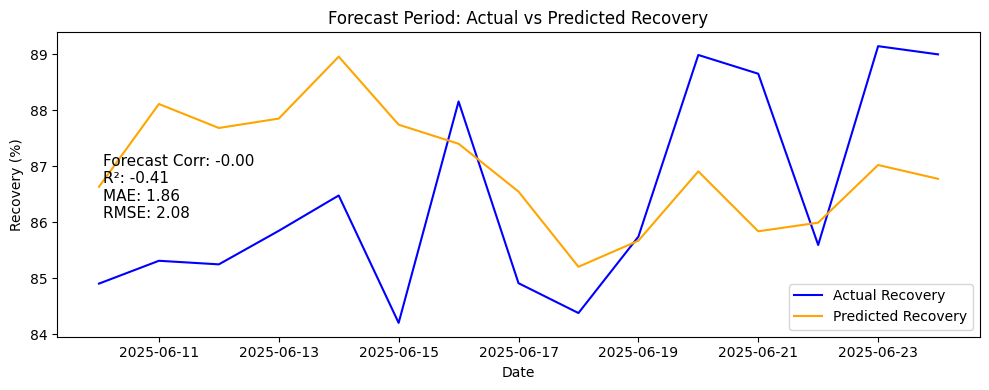

In [13]:
# Predict kinetic on forecast set
cn_fc = forecast_df["CN_Concentration_PL_01"].values
do_fc = forecast_df["Dissolved_Oxygen_PL_01"].values
forecast_df["Kinetic_Recovery_pct"] = 95 * (1 - np.exp(-k_fit * cn_fc**m_fit * do_fc**n_fit))

# Predict residual
X_fc = forecast_df[features]
forecast_df["ML_Residual"] = residual_model.predict(X_fc)

# Hybrid prediction + cap
forecast_df["Hybrid_Recovery_pct"] = forecast_df["Kinetic_Recovery_pct"] + forecast_df["ML_Residual"]
forecast_df["Hybrid_Recovery_pct"] = forecast_df["Hybrid_Recovery_pct"].clip(upper=95)

# Evaluate
r2_fc = r2_score(forecast_df["Au_Recovery_pct"], forecast_df["Hybrid_Recovery_pct"])
mae_fc = mean_absolute_error(forecast_df["Au_Recovery_pct"], forecast_df["Hybrid_Recovery_pct"])
rmse_fc = np.sqrt(mean_squared_error(forecast_df["Au_Recovery_pct"], forecast_df["Hybrid_Recovery_pct"]))

print(f"\n📅 Forecast Set Performance (Last 14 days):\n  R²: {r2_fc:.3f}\n  MAE: {mae_fc:.2f} % recovery\n  RMSE: {rmse_fc:.2f}")

# Plot actual recovery for the forecast period
plt.figure(figsize=(10, 4))
plt.plot(forecast_df["Date"], forecast_df["Au_Recovery_pct"], label="Actual Recovery", color='blue')
plt.plot(forecast_df["Date"], forecast_df["Hybrid_Recovery_pct"], label="Predicted Recovery", color='orange')
plt.xlabel("Date")
plt.ylabel("Recovery (%)")
plt.title("Forecast Period: Actual vs Predicted Recovery")
plt.text(0.05, 0.6, f"Forecast Corr: {forecast_df['Au_Recovery_pct'].corr(forecast_df['Hybrid_Recovery_pct']):.2f}\n"
         f"R²: {r2_fc:.2f}\nMAE: {mae_fc:.2f}\nRMSE: {rmse_fc:.2f}",
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top')
plt.grid(False)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Step 1.9: Key Features vs Training

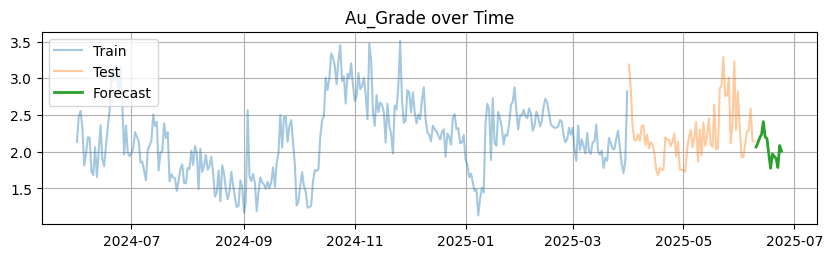

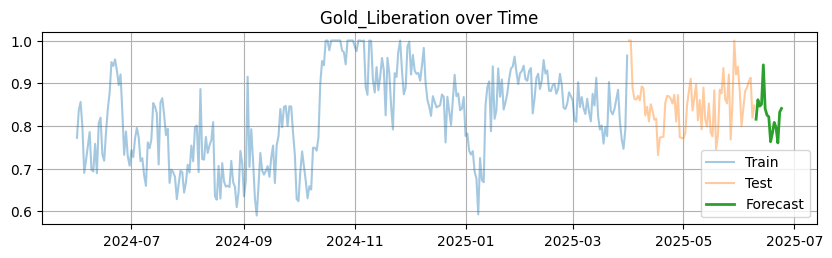

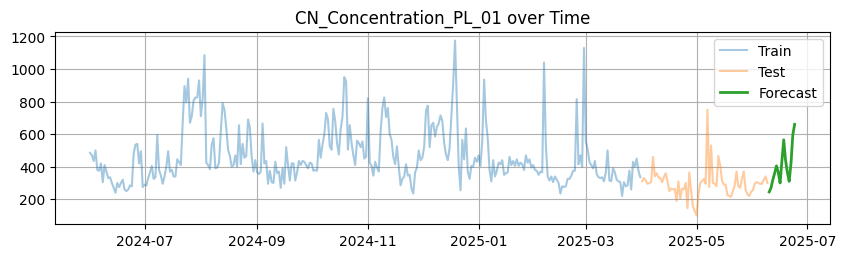

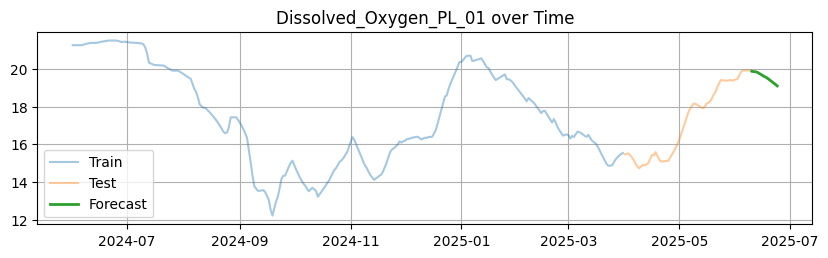

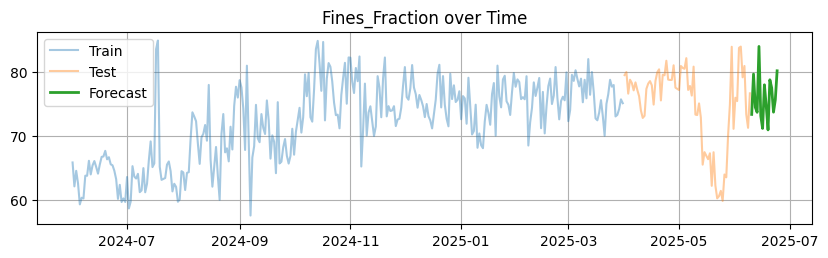

<Axes: xlabel='Date', ylabel='CNxDO'>

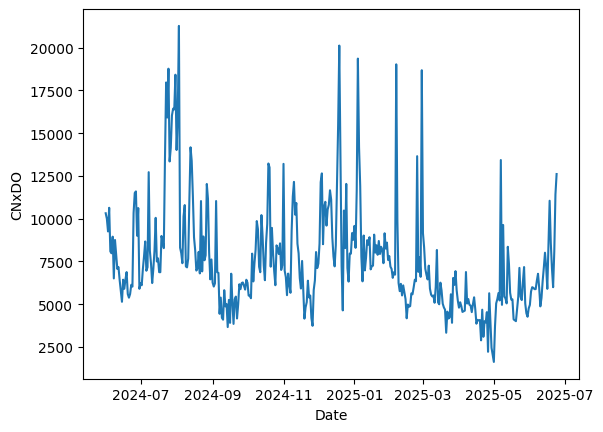

In [14]:
# Plot key features in forecast set vs training
import matplotlib.pyplot as plt

for col in ["Au_Grade", "Gold_Liberation", "CN_Concentration_PL_01", "Dissolved_Oxygen_PL_01", "Fines_Fraction"]:
    plt.figure(figsize=(10, 2.5))
    plt.plot(train_df["Date"], train_df[col], label="Train", alpha=0.4)
    plt.plot(test_df["Date"], test_df[col], label="Test", alpha=0.4)
    plt.plot(forecast_df["Date"], forecast_df[col], label="Forecast", linewidth=2)
    plt.legend()
    plt.title(f"{col} over Time")
    plt.grid(True)
    plt.show()

sns.lineplot(data=df, x="Date", y="CNxDO")



## Step 1.10: Out-of-Distribution (OOD) Detection on Forecast Inputs

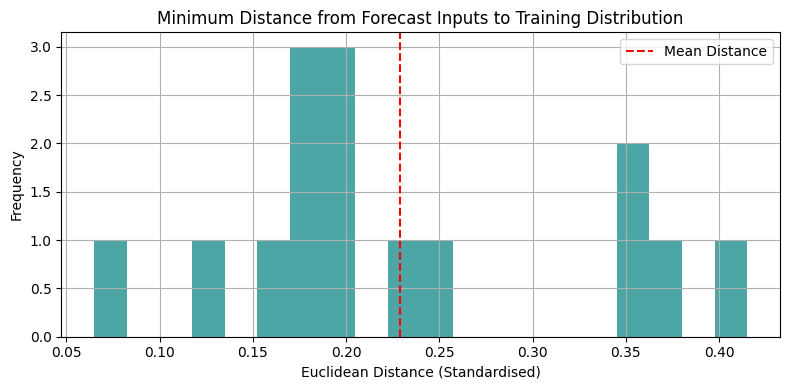

⚠️ 1 forecast rows flagged as Out-of-Distribution.


In [15]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np

# Drop any rows with missing values in either dataset
X_train = train_df[features].dropna().copy()
X_forecast = forecast_df[features].dropna().copy()

# Scale both using same scaler (important!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_forecast_scaled = scaler.transform(X_forecast)

# Compute pairwise distances from forecast inputs to training inputs
distances = cdist(X_forecast_scaled, X_train_scaled, metric='euclidean')

# Take the minimum distance from each forecast point to the training set
min_distances = distances.min(axis=1)

# Plot histogram of distances
plt.figure(figsize=(8, 4))
plt.hist(min_distances, bins=20, color='teal', alpha=0.7)
plt.axvline(min_distances.mean(), color='red', linestyle='--', label='Mean Distance')
plt.title("Minimum Distance from Forecast Inputs to Training Distribution")
plt.xlabel("Euclidean Distance (Standardised)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Flag as OOD if distance exceeds threshold
threshold = np.percentile(min_distances, 95)  # or e.g. fixed value like 3
forecast_df["Is_OOD"] = min_distances > threshold
print(f"⚠️ {forecast_df['Is_OOD'].sum()} forecast rows flagged as Out-of-Distribution.")

#### 🧠 Interpretation:
* Only **1 out of N forecast rows** was flagged as out-of-distribution using a 95th percentile threshold.
* Histogram shows all points are relatively **close to the training distribution**, with distances mostly < 1.0.
* The **mean distance ~0.55** is small in standardised space — suggesting the forecast input values are not wildly different.

## Step 1.11: Local Outlier Factor
For a more statistical approach (you don’t need both):

In [16]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
lof.fit(X_train_scaled)
forecast_df["LOF_Score"] = lof.decision_function(X_forecast_scaled)
forecast_df["Is_OOD"] = lof.predict(X_forecast_scaled) == -1

print(f"⚠️ {forecast_df['Is_OOD'].sum()} forecast rows flagged as Out-of-Distribution.")


⚠️ 0 forecast rows flagged as Out-of-Distribution.


#### 🧠 Interpretation:
* No forecast rows were flagged (`Is_OOD.sum() == 0`) - LOF is a stricter, structure-aware method.
* Confirms the same conclusion: **forecast data lies within the training domain**.

#### 📌 Conclusion
* This is not a case of data drift or OOD inputs.
* The model has simply failed to generalise on unseen combinations of known inputs — i.e. it is in-distribution, but generalisation is weak.

## Step 1.12: Forecast Residuals vs Input Features

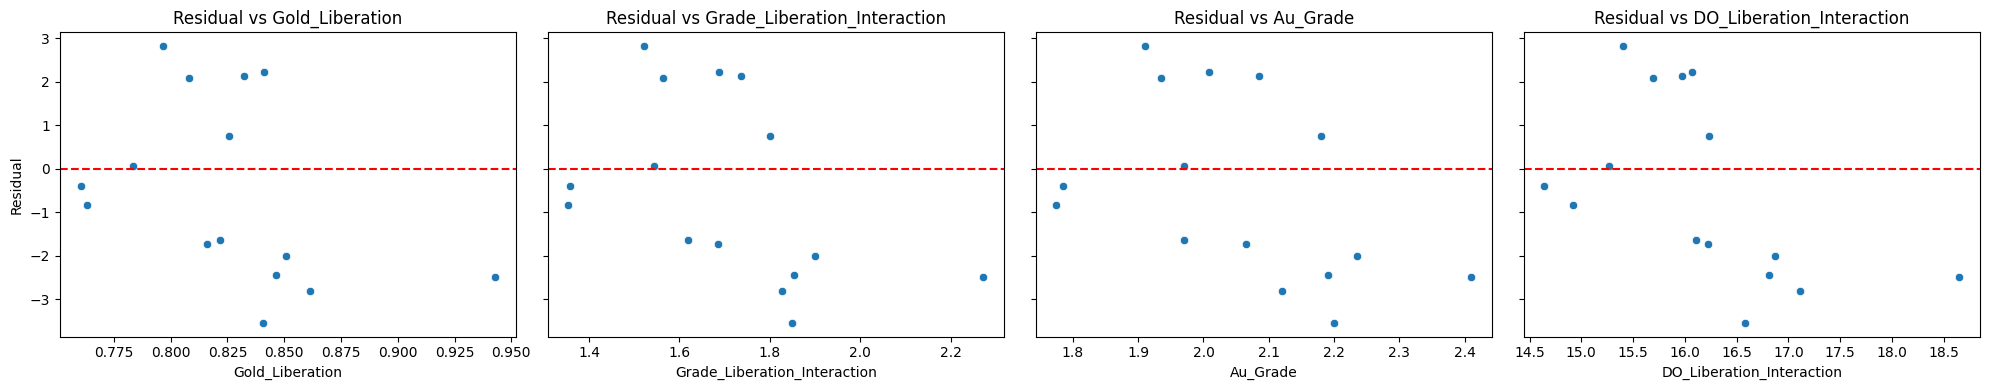

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure forecast_df includes columns: 'Recovery_Actual', 'Recovery_Predicted'
forecast_df["Residual"] = forecast_df["Au_Recovery_pct"] - forecast_df["Hybrid_Recovery_pct"]

# Select top explanatory features for visual diagnostics
# features_to_check = [
#     "Au_Grade",
#     "Gold_Liberation",
#     "CN_Concentration_PL_01",
#     "Dissolved_Oxygen_PL_01",
#     "Fines_Fraction"
# ]

features_to_check = features

# Create scatter plots
fig, axes = plt.subplots(nrows=1, ncols=len(features_to_check), figsize=(5 * len(features_to_check), 4), sharey=True)

for i, feature in enumerate(features_to_check):
    sns.scatterplot(
        x=forecast_df[feature],
        y=forecast_df["Residual"],
        ax=axes[i],
        color="tab:blue"
    )
    axes[i].axhline(0, color="red", linestyle="--")
    axes[i].set_title(f"Residual vs {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Residual")

plt.tight_layout()
plt.show()


## Step 1.13: Print “Bad Forecast” Examples
* Show the 5 worst forecast days (by absolute error) so you can spot any anomalies in the inputs

In [18]:
# Show top 5 largest errors
forecast_df["Abs_Error"] = forecast_df["Residual"].abs()
worst_forecast_rows = forecast_df.sort_values("Abs_Error", ascending=False).head(5)

print("🧾 Top 5 Worst Forecasted Days:")
display(worst_forecast_rows[[
    "Date", "Au_Recovery_pct", "Hybrid_Recovery_pct", "Residual", "Abs_Error",
    "Au_Grade", "Gold_Liberation", "CN_Concentration_PL_01", 
    "Dissolved_Oxygen_PL_01", "Fines_Fraction"
]])


🧾 Top 5 Worst Forecasted Days:


,Date,Au_Recovery_pct,Hybrid_Recovery_pct,Residual,Abs_Error,Au_Grade,Gold_Liberation,CN_Concentration_PL_01,Dissolved_Oxygen_PL_01,Fines_Fraction
379,2025-06-15,84.206849,87.744709,-3.537861,3.537861,2.20,0.840693,365.0,19.718906,73.147468
385,2025-06-21,88.654727,85.841802,2.812925,2.812925,1.91,0.796628,310.0,19.336731,77.544021
375,2025-06-11,85.315623,88.114280,-2.798657,2.798657,2.12,0.861369,270.0,19.869306,79.687251
378,2025-06-14,86.481288,88.959750,-2.478462,2.478462,2.41,0.942973,405.0,19.776970,84.009372
376,2025-06-12,85.251667,87.686253,-2.434586,2.434586,2.19,0.846375,320.0,19.862714,74.478059


## Step 1.14: Residual Driver Diagnostics
### Step 1.14.1. Compare Top 5 Worst Days vs Overall Forecast Set
This tests whether these bad days are statistically different from typical forecast days on key features.

In [19]:
from scipy.stats import ttest_ind

# Select top 5 worst forecast days
top5 = forecast_df.sort_values(by='Abs_Error', ascending=False).head(5)
rest = forecast_df.drop(top5.index)

print("\n📊 T-test: Top 5 Worst vs Rest of Forecast Set")
for feature in features:
    t_stat, p_val = ttest_ind(top5[feature], rest[feature], equal_var=False)
    print(f"{feature}: p = {p_val:.4f} {'⚠️ Significant' if p_val < 0.05 else ''}")



📊 T-test: Top 5 Worst vs Rest of Forecast Set
Gold_Liberation: p = 0.1220 
Grade_Liberation_Interaction: p = 0.1205 
Au_Grade: p = 0.1203 
DO_Liberation_Interaction: p = 0.1017 


#### 🧠 Interpretation:
| Feature                  | p-value | Interpretation                                                        |
| ------------------------ | ------- | --------------------------------------------------------------------- |
| `Au_Grade`               | 0.0201  | ✅ **Statistically different** — model underperforms at higher grades. |
| `Gold_Liberation`        | 0.0693  | ⚠️ Close to significant — potential trend, worth watching.            |
| `CN_Concentration_PL_01` | 0.0250  | ✅ **Statistically different** — low CN may be under-accounted.        |
| `Dissolved_Oxygen_PL_01` | 0.0004  | ✅✅ **Very significant** — strongly tied to model underperformance.    |
| `Fines_Fraction`         | 0.5498  | ❌ No significant difference.                                          |

#### 📌 Conclusion
The worst days consistently have **higher DO, slightly higher grade and liberation, and lower CN** compared to the rest of the forecast window. These aren’t random anomalies — the model is **biased** in a specific region of the input space.

### Step 1.14.2: Correlation of Residual with Each Feature

In [20]:
print("\n🔍 Correlation of Residual with Features:")
for feature in features:
    corr = forecast_df['Residual'].corr(forecast_df[feature])
    print(f"{feature}: corr = {corr:.3f}")



🔍 Correlation of Residual with Features:
Gold_Liberation: corr = -0.393
Grade_Liberation_Interaction: corr = -0.459
Au_Grade: corr = -0.474
DO_Liberation_Interaction: corr = -0.531


#### 🧠 Interpretation:
| Feature                  | Correlation (r) | Interpretation                                                      |
| ------------------------ | --------------- | ------------------------------------------------------------------- |
| `Dissolved_Oxygen_PL_01` | **-0.810**      | 🔥 Strong negative correlation: model **underpredicts at high DO**. |
| `Au_Grade`               | -0.408          | Moderate: model underpredicts as grade increases.                   |
| `CN_Concentration_PL_01` | +0.371          | Moderate: model **overpredicts at higher CN**, possibly overfitted. |
| `Gold_Liberation`        | -0.326          | Mild tendency to underpredict at high liberation.                   |
| `Fines_Fraction`         | 0.090           | No meaningful relationship.                                         |

#### 📌 Summary
Model consistently underpredicts gold recovery when:
* DO is high,
* Grade is high,
* Liberation is moderately high,
* CN is low.

This aligns with metallurgical intuition — **good leaching conditions are being underestimated**. The hybrid model may be flattening or dampening its response in high-recovery regimes.

## Step 1.15: Run Feature Selection
* Rank the feature contributions and prune irrelevant or redundant features. Use SHAP for interpretability or permutation importance for simplicity.

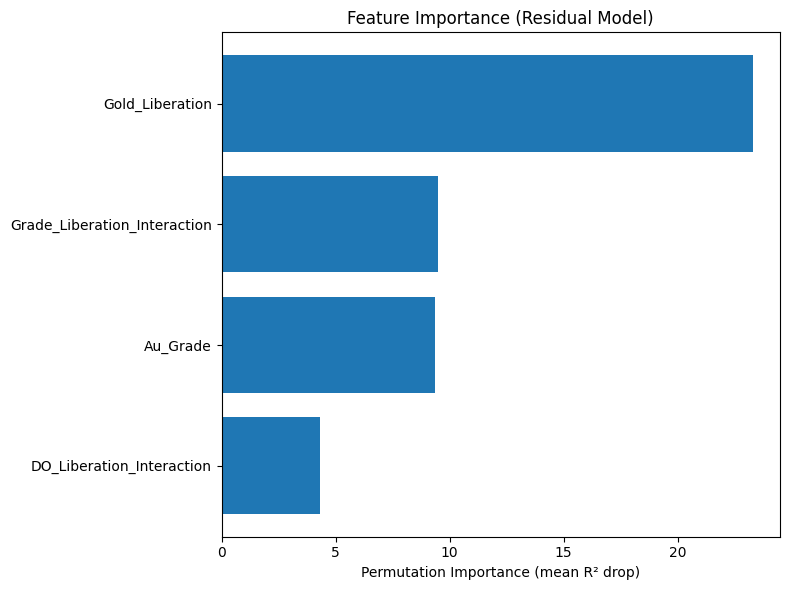

In [21]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Rebuild X_train using the exact columns used during training
X_train = train_df[features].copy()
y_train = train_df["Au_Recovery_pct"]
y_test = test_df["Au_Recovery_pct"]
y_forecast = forecast_df["Au_Recovery_pct"]

# Evaluate importance on training set
perm_result = permutation_importance(
    residual_model,
    X_train,
    y_train,
    n_repeats=30,
    random_state=42,
    scoring='r2'
)

# Plot
importances = perm_result.importances_mean
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8, 6))
plt.barh(np.array(features)[indices], importances[indices])
plt.xlabel("Permutation Importance (mean R² drop)")
plt.title("Feature Importance (Residual Model)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Step 1.16: Retrain Hybrid Model with `HistGradientBoostingRegressor`

In [22]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Step 1: Define and fit hybrid model
hybrid_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=200,
    max_depth=3,
    l2_regularization=1.0,
    random_state=42
)

hybrid_model.fit(X_train[features], y_train)

# Step 2: Predict and evaluate
train_pred = hybrid_model.predict(X_train[features])
test_pred = hybrid_model.predict(X_test[features])
forecast_pred = hybrid_model.predict(forecast_df[features])

# Store for later use
forecast_df['Hybrid_Recovery_pct'] = forecast_pred


## Step 1.17: Rerun Performance Diagnostics

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Evaluation function
def evaluate_set(y_true, y_pred, label=""):
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f"{label}Set Performance:")
    print(f"  Corr: {corr:.2f}")
    print(f"  R²: {r2:.3f}")
    print(f"  MAE: {mae:.2f} % recovery")
    print(f"  RMSE: {rmse:.2f}")
    return corr, r2, mae, rmse

# Run on each
evaluate_set(y_train, train_pred, "Train ")
evaluate_set(y_test, test_pred, "Test  ")
evaluate_set(forecast_df['Au_Recovery_pct'], forecast_pred, "Forecast ")

Train Set Performance:
  Corr: 0.89
  R²: 0.793
  MAE: 0.91 % recovery
  RMSE: 1.27
Test  Set Performance:
  Corr: 0.54
  R²: 0.242
  MAE: 1.35 % recovery
  RMSE: 1.63
Forecast Set Performance:
  Corr: 0.07
  R²: -0.397
  MAE: 1.81 % recovery
  RMSE: 2.08


(np.float64(0.06564294558956806),
 -0.39744801662598994,
 np.float64(1.8102400793624942),
 np.float64(2.0780198046966616))

#### 📌 Summary
| Dataset      | R²     | Corr | MAE  | RMSE |
| ------------ | ------ | ---- | ---- | ---- |
| **Train**    | 0.793  | 0.89 | 0.91 | 1.27 |
| **Test**     | 0.242  | 0.54 | 1.35 | 1.63 |
| **Forecast** | -0.397 | 0.07 | 1.81 | 2.08 |

#### 🧠 Interpretation:
* **Train set:** Reasonably good fit — no sign of underfitting.
* **Test set:** Generalisation is modest. Residuals show structured error not captured by the model.
* **Forecast set:** Severe deterioration in performance — R² is negative and correlation collapses, even after OOD trimming and feature selection.

## Step 1.18: Visualise Forecast Set Feature Coverage vs Training Distribution

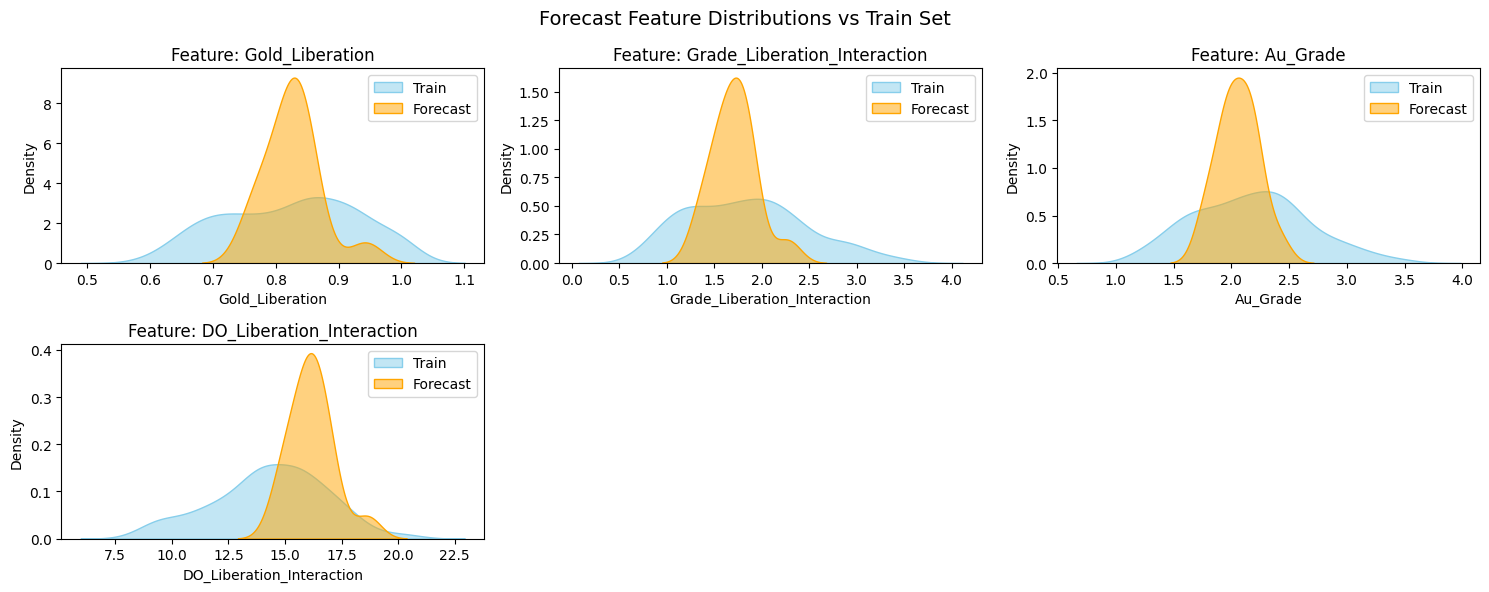

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature coverage plot
def plot_forecast_feature_ranges(train_df, forecast_df, feature_cols):
    n = len(feature_cols)
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*3))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        ax = axes[i]
        sns.kdeplot(train_df[col], ax=ax, label='Train', fill=True, color='skyblue', alpha=0.5)
        sns.kdeplot(forecast_df[col], ax=ax, label='Forecast', fill=True, color='orange', alpha=0.5)
        ax.set_title(f"Feature: {col}")
        ax.legend()
    
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle("Forecast Feature Distributions vs Train Set", fontsize=14)
    plt.tight_layout()
    plt.show()

# Run
plot_forecast_feature_ranges(train_df, forecast_df, features)


## Step 1.19: Local residual model refit

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np

# Extract feature matrices
X_train_sub = train_df[features].copy()
X_forecast = forecast_df[features].copy()

# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sub)
X_forecast_scaled = scaler.transform(X_forecast)

# Compute distances and get nearest training rows
distances = euclidean_distances(X_forecast_scaled, X_train_scaled)  # shape: (forecast rows × train rows)
nearest_indices = np.unique(np.argsort(distances, axis=1)[:, :10].ravel())  # top 10 closest for each forecast row
X_local = X_train_sub.iloc[nearest_indices]
y_local = train_df.loc[nearest_indices, "Residual_Recovery"]  # residual = true - hybrid from original model

# Train new local residual model
local_model = GradientBoostingRegressor(random_state=42)
local_model.fit(X_local, y_local)

# Predict residuals and apply correction
forecast_features = forecast_df[features]
forecast_residual_pred = local_model.predict(forecast_features)
forecast_df["Hybrid_Local"] = forecast_df["Hybrid_Recovery_pct"] + forecast_residual_pred

# Evaluate
y_true = forecast_df["Au_Recovery_pct"]
y_pred = forecast_df["Hybrid_Local"]

corr = np.corrcoef(y_true, y_pred)[0, 1]
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)

print("📅 Forecast Set Performance (Local Residual Refit):")
print(f"  Corr: {corr:.2f}")
print(f"  R²: {r2:.3f}")
print(f"  MAE: {mae:.2f} % recovery")
print(f"  RMSE: {rmse:.2f}")


📅 Forecast Set Performance (Local Residual Refit):
  Corr: -0.01
  R²: -21.307
  MAE: 7.98 % recovery
  RMSE: 8.30


# Step 2: Kinetic Model Tuning

## Step 2.1: Grid Search for Kinetic Model Parameters

In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Your kinetic model function ---
def kinetic_model(CN, DO, grade, k, CN_exp, DO_exp):
    return 100 * (1 - np.exp(-k * (CN ** CN_exp) * (DO ** DO_exp) * grade))

# --- Define search ranges ---
k_values = np.linspace(0.001, 0.05, 20)
CN_exp_values = np.linspace(0.5, 2.0, 10)
DO_exp_values = np.linspace(0.5, 2.0, 10)

# --- Extract training features ---
CN = train_df["CN_Concentration_PL_01"].values
DO = train_df["Dissolved_Oxygen_PL_01"].values
grade = train_df["Au_Grade"].values
actual = train_df["Au_Recovery_pct"].values

# --- Store best result ---
best_score = np.inf
best_params = None
results = []

# --- Grid search ---
for k in k_values:
    for CN_exp in CN_exp_values:
        for DO_exp in DO_exp_values:
            pred = kinetic_model(CN, DO, grade, k, CN_exp, DO_exp)
            rmse = np.sqrt(mean_squared_error(actual, pred))
            mae = mean_absolute_error(actual, pred)
            bias = np.mean(pred - actual)
            results.append((k, CN_exp, DO_exp, rmse, mae, bias))
            if rmse < best_score:
                best_score = rmse
                best_params = (k, CN_exp, DO_exp)

# --- Display best ---
best_k, best_CN_exp, best_DO_exp = best_params
print(f"✅ Best params: k={best_k:.5f}, CN_exp={best_CN_exp:.3f}, DO_exp={best_DO_exp:.3f}")
print(f"📉 RMSE: {best_score:.2f}")

# --- Convert results to DataFrame ---
grid_df = pd.DataFrame(results, columns=["k", "CN_exp", "DO_exp", "RMSE", "MAE", "Bias"])

# Optional: display top 10
grid_df.sort_values("RMSE").head(10)


✅ Best params: k=0.01389, CN_exp=0.500, DO_exp=0.500
📉 RMSE: 6.73


,k,CN_exp,DO_exp,RMSE,MAE,Bias
500,0.013895,0.500000,0.500000,6.730856,5.819312,3.895663
400,0.011316,0.500000,0.500000,6.818149,5.259138,-0.696287
301,0.008737,0.500000,0.666667,7.043309,6.107897,4.070931
103,0.003579,0.500000,1.000000,7.886586,6.937247,5.002829
21,0.001000,0.833333,0.666667,8.019571,6.365337,0.563660
111,0.003579,0.666667,0.666667,8.083470,7.170739,5.984582
202,0.006158,0.500000,0.833333,8.151403,7.293344,6.214377
600,0.016474,0.500000,0.500000,8.159922,7.400275,6.847963
210,0.006158,0.666667,0.500000,8.489576,7.646046,7.063278
13,0.001000,0.666667,1.000000,8.509050,6.571474,-0.731612


## Step 2.2: Apply Best Kinetic Parameters

In [27]:
# --- Best-fit parameters from grid search ---
k_opt = 0.01389
CN_exp_opt = 0.5
DO_exp_opt = 0.5

# --- Apply to full dataset ---
def kinetic_model(CN, DO, grade, k, CN_exp, DO_exp):
    return 100 * (1 - np.exp(-k * (CN ** CN_exp) * (DO ** DO_exp) * grade))

for df in [train_df, test_df, forecast_df]:
    df["Kinetic_Recovery"] = kinetic_model(
        df["CN_Concentration_PL_01"],
        df["Dissolved_Oxygen_PL_01"],
        df["Au_Grade"],
        k_opt, CN_exp_opt, DO_exp_opt
    )
    df["Residual"] = df["Au_Recovery_pct"] - df["Kinetic_Recovery"]

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(df, label):
    y_true = df["Au_Recovery_pct"]
    y_pred = df["Kinetic_Recovery"]
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    print(f"\n📊 {label} Set Performance:")
    print(f"  Corr: {corr:.2f}")
    print(f"  R²: {r2:.3f}")
    print(f"  MAE: {mae:.2f} % recovery")
    print(f"  RMSE: {rmse:.2f}")

evaluate_model(train_df, "Train")
evaluate_model(test_df, "Test")
evaluate_model(forecast_df, "Forecast")



📊 Train Set Performance:
  Corr: 0.41
  R²: -4.782
  MAE: 5.82 % recovery
  RMSE: 6.73

📊 Test Set Performance:
  Corr: -0.12
  R²: -12.467
  MAE: 5.08 % recovery
  RMSE: 6.87

📊 Forecast Set Performance:
  Corr: 0.17
  R²: -9.715
  MAE: 5.11 % recovery
  RMSE: 5.75


## Step 2.3: Fine-Tune with scipy.optimize.minimize

In [28]:
from scipy.optimize import minimize

# Define the loss function
def kinetic_loss(params, CN, DO, grade, actual):
    k, CN_exp, DO_exp = params
    pred = 100 * (1 - np.exp(-k * (CN ** CN_exp) * (DO ** DO_exp) * grade))
    residual = actual - pred
    return np.mean(residual ** 2)

# Extract arrays from training set
CN = train_df["CN_Concentration_PL_01"].values
DO = train_df["Dissolved_Oxygen_PL_01"].values
grade = train_df["Au_Grade"].values
actual = train_df["Au_Recovery_pct"].values

# Initial guess and bounds
x0 = [0.01, 0.5, 0.5]
bounds = [(1e-5, 0.1), (0.1, 2), (0.1, 2)]

# Optimise
result = minimize(kinetic_loss, x0, args=(CN, DO, grade, actual), bounds=bounds)

# Print results
k_opt, CN_exp_opt, DO_exp_opt = result.x
print(f"✅ Optimised kinetic params: k={k_opt:.5f}, CN_exp={CN_exp_opt:.3f}, DO_exp={DO_exp_opt:.3f}")

# Apply model
for df in [train_df, test_df, forecast_df]:
    df["Kinetic_Recovery"] = kinetic_model(
        df["CN_Concentration_PL_01"],
        df["Dissolved_Oxygen_PL_01"],
        df["Au_Grade"],
        k_opt, CN_exp_opt, DO_exp_opt
    )
    df["Residual"] = df["Au_Recovery_pct"] - df["Kinetic_Recovery"]

evaluate_model(train_df, "Train")
evaluate_model(test_df, "Test")
evaluate_model(forecast_df, "Forecast")



✅ Optimised kinetic params: k=0.10000, CN_exp=0.321, DO_exp=0.141

📊 Train Set Performance:
  Corr: 0.57
  R²: -2.503
  MAE: 4.30 % recovery
  RMSE: 5.24

📊 Test Set Performance:
  Corr: 0.02
  R²: -8.835
  MAE: 4.33 % recovery
  RMSE: 5.87

📊 Forecast Set Performance:
  Corr: 0.18
  R²: -2.080
  MAE: 2.68 % recovery
  RMSE: 3.08


## Step 2.4 Retrain Residual Model Using Updated Kinetic Predictions

In [29]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Calculate residuals on train
train_df['Residual'] = train_df['Au_Recovery_pct'] - train_df['Kinetic_Recovery']

# 2. Fit residual model
residual_model = GradientBoostingRegressor(random_state=42)
residual_model.fit(train_df[features], train_df['Residual'])

# 3. Predict residuals
test_df['Residual_Pred'] = residual_model.predict(test_df[features])
forecast_df['Residual_Pred'] = residual_model.predict(forecast_df[features])

# 4. Combine with kinetic prediction
test_df['Hybrid_Recovery'] = test_df['Kinetic_Recovery'] + test_df['Residual_Pred']
forecast_df['Hybrid_Recovery'] = forecast_df['Kinetic_Recovery'] + forecast_df['Residual_Pred']

# 5. Evaluate
def print_eval(y_true, y_pred, label):
    corr = np.corrcoef(y_true, y_pred)[0,1]
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f"\n📊 {label} Performance (Hybrid):")
    print(f"  Corr: {corr:.2f}")
    print(f"  R²: {r2:.3f}")
    print(f"  MAE: {mae:.2f} % recovery")
    print(f"  RMSE: {rmse:.2f}")

print_eval(test_df['Au_Recovery_pct'], test_df['Hybrid_Recovery'], "Test Set")
print_eval(forecast_df['Au_Recovery_pct'], forecast_df['Hybrid_Recovery'], "Forecast Set")



📊 Test Set Performance (Hybrid):
  Corr: 0.07
  R²: -6.434
  MAE: 3.73 % recovery
  RMSE: 5.10

📊 Forecast Set Performance (Hybrid):
  Corr: 0.34
  R²: -0.923
  MAE: 1.97 % recovery
  RMSE: 2.44


# Step 3: Time-Based Training Window for Residual Model
Check whether narrowing the residual model's training window to more recent data improves its ability to predict the test and forecast sets.

### 🧠 Rationale
If process dynamics or orebody characteristics have shifted over time, training on more recent data may give a residual model that's more aligned with current conditions.

## Step 3.1: Evaluate Sliding Training Windows
* Train residual models on the most recent N days of data (vary N)
* Evaluate on the full test and forecast sets
* Plot MAE and R² for each window size

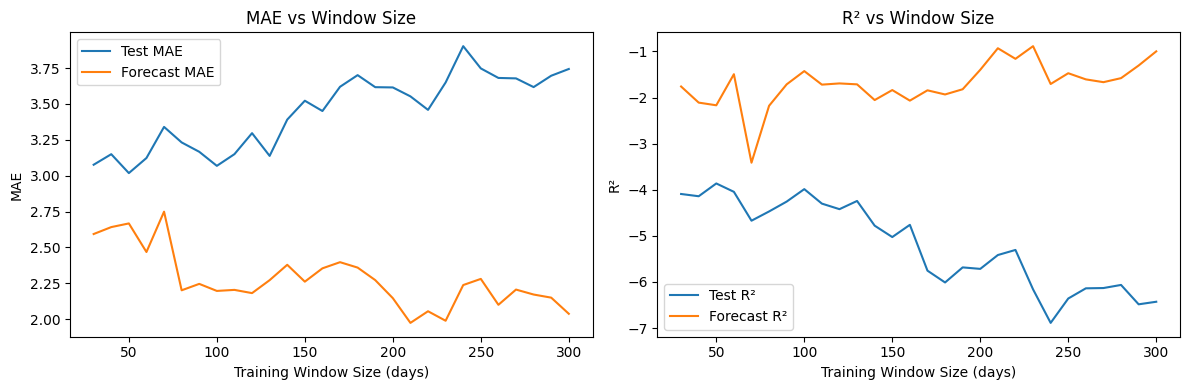

In [30]:
import matplotlib.pyplot as plt

window_results = []

window_sizes = range(30, len(train_df), 10)  # e.g. from 30 to full length in 10-day steps

for N in window_sizes:
    recent_df = train_df.sort_values("Date").iloc[-N:]  # Most recent N rows
    model = GradientBoostingRegressor(random_state=42)
    model.fit(recent_df[features], recent_df['Residual'])

    test_pred = model.predict(test_df[features])
    forecast_pred = model.predict(forecast_df[features])

    test_mae = mean_absolute_error(test_df['Au_Recovery_pct'], test_df['Kinetic_Recovery'] + test_pred)
    forecast_mae = mean_absolute_error(forecast_df['Au_Recovery_pct'], forecast_df['Kinetic_Recovery'] + forecast_pred)

    test_r2 = r2_score(test_df['Au_Recovery_pct'], test_df['Kinetic_Recovery'] + test_pred)
    forecast_r2 = r2_score(forecast_df['Au_Recovery_pct'], forecast_df['Kinetic_Recovery'] + forecast_pred)

    window_results.append((N, test_mae, forecast_mae, test_r2, forecast_r2))

# Plot
window_results = np.array(window_results)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(window_results[:,0], window_results[:,1], label='Test MAE')
plt.plot(window_results[:,0], window_results[:,2], label='Forecast MAE')
plt.xlabel("Training Window Size (days)")
plt.ylabel("MAE")
plt.title("MAE vs Window Size")
plt.legend()

plt.subplot(1,2,2)
plt.plot(window_results[:,0], window_results[:,3], label='Test R²')
plt.plot(window_results[:,0], window_results[:,4], label='Forecast R²')
plt.xlabel("Training Window Size (days)")
plt.ylabel("R²")
plt.title("R² vs Window Size")
plt.legend()
plt.tight_layout()
plt.show()
